<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
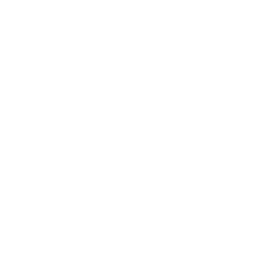
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Teollisuuslaakereiden kulumisen tunnistus</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Luotettavuustekniikka &nbsp;|&nbsp; Maaliskuu 2026</p>
</div>
</div>
</div>

## Yhteenveto

100 teollisuuslaakerin laivue on valvonnassa kiinteän huoltoaikataulun mukaisesti. Kulumisen ylittäminen sallitun toleranssin voi havaita vain suunnitelluissa seisokeissa, joten aikaa kulumisen alkamiseen ei koskaan havaita tarkasti — se on **väliaikasensuroitu** viimeisimmän hyväksytyn tarkastuksen (`last_ok_hours`) ja ensimmäisen epäonnistuneen tarkastuksen (`first_worn_hours`) välillä. Laakerit, jotka olivat vielä toleranssin sisällä viimeisessä tarkastuksessaan, ovat oikealta sensuroituja.

PROC ICLIFETEST sovittaa Turnbullin ei-parametrisen estimaattorin kulumisvapaalle eloonjäämisfunktiolle ja vertaa kahta voiteluainejärjestelmää (Synteettinen vs. Mineraali). Analyysi vastaa konkreettiseen huoltokysymykseen: **pidentääkö synteettinen voiteluaine merkittävästi laakerin kulumisvapaata käyttöikää?** Jokainen alla lainattu luku on luettu suoraan proseduurin suoritetusta tulosteesta.


## Tietolähde

| Aineisto | N | Kuvaus |
|---------|---|-------------|
| `bearing_inspections` | 100 | Yksi rivi per laakeri: voiteluaine, kuormitus, kierrosnopeus ja kulumisen alkamisen rajaava tarkastusväli |

Väliaikasensuroitu vaste on pari `(last_ok_hours, first_worn_hours)`. Puuttuva `first_worn_hours` merkitsee laakeria, joka oli vielä toleranssin sisällä viimeisessä tarkastuksessaan (oikealta sensuroitu).


---

In [1]:
/* Laakereiden kulumistarkastusaineisto: 100 laakeria, kaksi voiteluainejärjestelmää.
   Synteettinen voiteluaine on suunniteltu pidentämään kulumisvapaata käyttöikää,
   joten eloonjäämiskäyrät erkanevat fysikaalisesti uskottavaan suuntaan. */
TIEDOT bearing_inspections;
    CALL streaminit(42);
    TAULUKKO lubes[2] $16 ('Synteettinen' 'Mineraali');
    TEE bearing_id = 1 ASTI 100;
        lubricant = lubes[ceil(rand('uniform') * 2)];
        load_kn   = round(10 + rand('exponential') * 15, 0.1);
        rpm       = round(1000 + rand('uniform') * 4000, 0);
        /* Synteettinen kalvo viivyttää mitattavan kulumisen alkamista */
        JOS lubricant = 'Synteettinen' NIIN BASE = 2600; MUUTEN BASE = 1500;
        last_ok_hours    = round(rand('uniform') * BASE, 0);
        first_worn_hours = last_ok_hours + round(400 + rand('exponential') * 900, 0);
        /* ~25% edelleen kulumisvapaita viimeisessä tarkastuksessa -> oikealta sensuroitu */
        JOS rand('uniform') > 0.75 NIIN first_worn_hours = .;
        TULOSTE;
    LOPPU;
    POISTA i BASE;
    SÄILYTÄ bearing_id lubricant load_kn rpm last_ok_hours first_worn_hours;
SUORITA;



NOTE: DATA bearing_inspections


NOTE: Wrote bearing_inspections (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

### Käyttöolosuhteet voiteluaineittain

Ennen eloonjäämismallinnusta tehdään yhteenveto kunkin voiteluaineryhmän todellisesta käyttörasituksesta, jotta kulumisvapaan käyttöiän ero ei selity pelkästään kuormituksen tai nopeuden eroilla.


In [2]:
/* Käyttörasitus voiteluainejärjestelmittäin */
PROSEDUURI KESKIARVOT TIEDOT=bearing_inspections n mean std MAX maxdec=1;
    MUUTTUJA load_kn rpm;
    LUOKKA lubricant;
    NIMIKE lubricant="Voiteluaine" load_kn="Kuormitus (kN)" rpm="Kierrosnopeus (rpm)";
SUORITA;


                                                  The MEANS Procedure

                                       Analysis Variable : load_kn Kuormitus (kN)

        Voiteluaine           N Obs           Mean        Std Dev        Maximum
        ------------------------------------------------------------------------
        Mineraali                47           21.5            9.9           51.7
        Synteettinen             53           25.8           14.0           64.6
        ------------------------------------------------------------------------

                                      Analysis Variable : rpm Kierrosnopeus (rpm)

        Voiteluaine           N Obs           Mean        Std Dev        Maximum
        ------------------------------------------------------------------------
        Mineraali                47         2786.0         1093.5         4988.1
        Synteettinen             53         2949.7         1070.5         4773.5
        -------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Tarkastusikkuna suhteessa käyttökuormitukseen

Jokainen piste on yksi laakeri. Pystyakselin sijainti on viimeinen tunti, jolloin laakerin vahvistettiin olevan toleranssin sisällä; väri kuvaa voiteluainetta. Tämä näyttää raa'an altistumiskuvion, joka syötetään väliaikasensuroituun malliin.



NOTE: PROC SGPLOT data=bearing_inspections

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


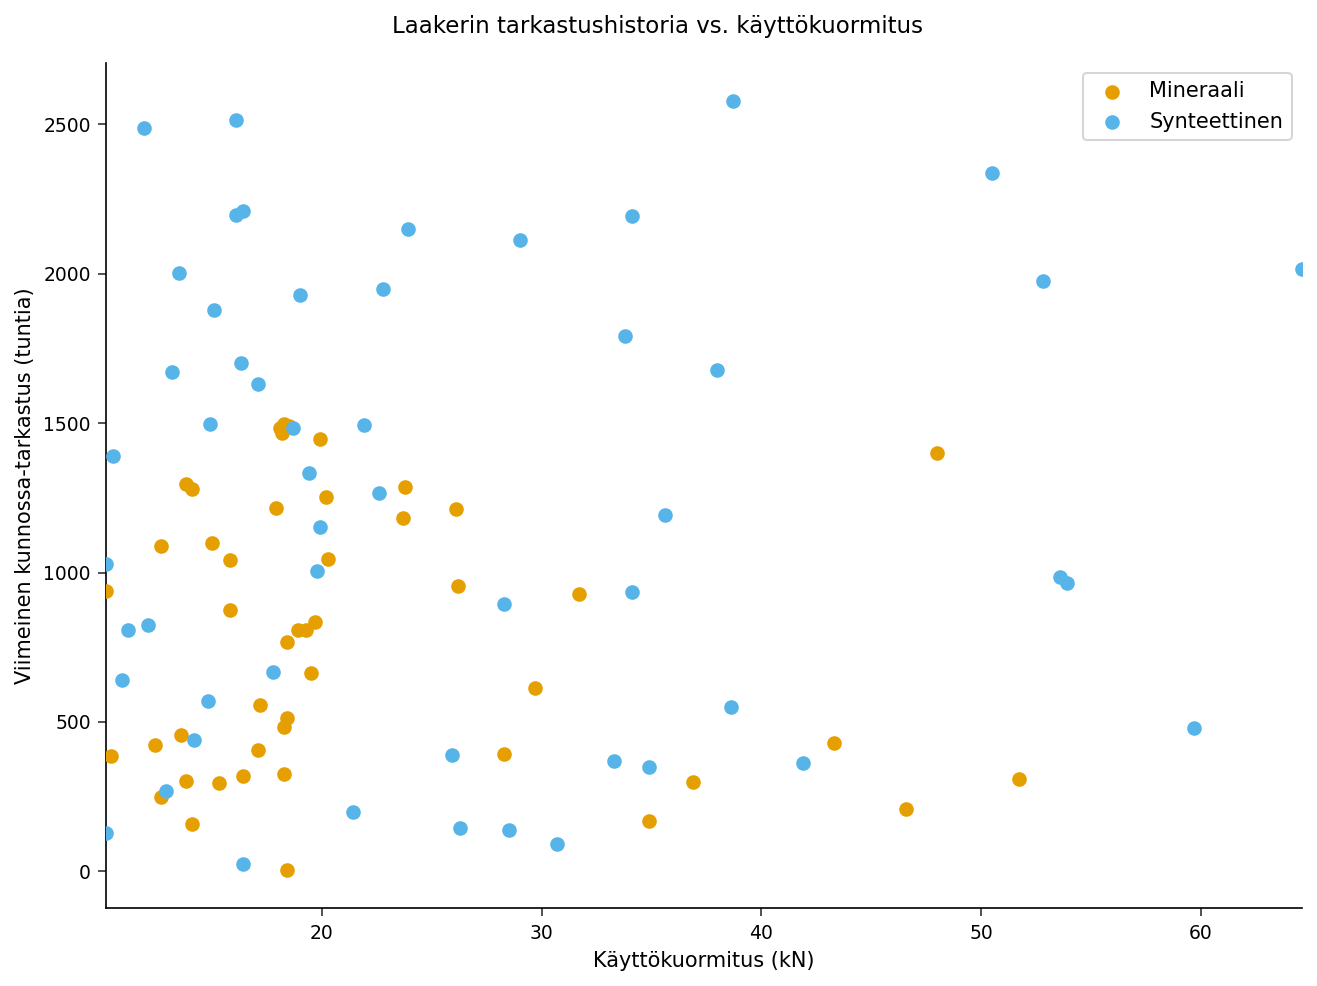

In [3]:
/* Viimeinen kunnossa-tarkastuksen tunti suhteessa kuormitukseen, voiteluaineittain */
PROSEDUURI SGPLOT TIEDOT=bearing_inspections;
    SCATTER x=load_kn y=last_ok_hours / GROUP=lubricant;
    XAXIS NIMIKE="Käyttökuormitus (kN)";
    YAXIS NIMIKE="Viimeinen kunnossa-tarkastus (tuntia)";
    OTSIKKO "Laakerin tarkastushistoria vs. käyttökuormitus";
SUORITA;


---

### Väliaikasensuroitu eloonjääminen voiteluaineittain

PROC ICLIFETEST laskee Turnbullin ei-parametrisen suurimman uskottavuuden estimaatin kulumisvapaalle eloonjäämisfunktiolle kullekin voiteluaineryhmälle, kirjoittaa koko eloonjäämistaulukon tiedostoon `surv_estimates.csv` ja piirtää ryhmitellyn eloonjäämiskuvaajan. Väliaikasensuroitu log-rank-testi testaa kahden eloonjäämisjakauman yhtäsuuruutta.



----------------------------------------------------------------------------------------------------------------------
                                               The ICLIFETEST Procedure                                               
----------------------------------------------------------------------------------------------------------------------
Left Bound Variable        Viimeksi kunnossa (h)
Right Bound Variable       Ensimmäinen kulunut (h)
Stratum Variable           Voiteluaine



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC ICLIFETEST data=bearing_inspections

NOTE: Using Python (numpy 2.4.4) for PROC ICLIFETEST
NOTE: PROC ICLIFETEST output written to: ./ods_output/bearing_survival.svg
NOTE: OUTSURV dataset written to: "./surv_estimates.csv"
NOTE: Interval-Censored Log-Rank Test: Chi-Square = 11.6806, p-value = 0.0006
NOTE: ODS Graphics is OFF.


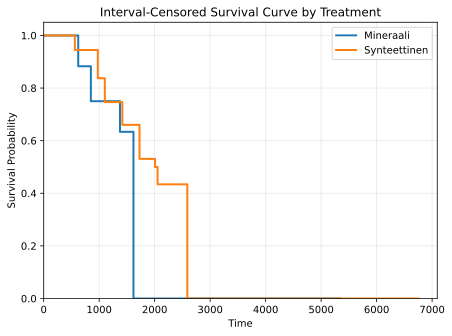

In [4]:
/* Turnbull-eloonjäämisestimaatti + ryhmitelty eloonjäämiskuvaaja + log-rank-testi */
ODS GRAPHICS ON;
ODS GRAPHICS / IMAGENAME='bearing_survival';
PROSEDUURI ICLIFETEST TIEDOT=bearing_inspections
                PLOTS=SURVIVAL
                outsurv='surv_estimates.csv';
    STRATA lubricant;
    TIME (last_ok_hours, first_worn_hours);
    NIMIKE lubricant="Voiteluaine" last_ok_hours="Viimeksi kunnossa (h)" first_worn_hours="Ensimmäinen kulunut (h)";
SUORITA;
ODS GRAPHICS OFF;


---

### Havainnot

Kaikki alla olevat luvut on luettu suoraan suoritetusta PROC MEANS -taulukosta,
Turnbullin eloonjäämisestimaateista tiedostossa `surv_estimates.csv` ja proseduurin lokista.

- **Otos.** 100 laakerista 53 käytti synteettistä ja 47 mineraalivoiteluainetta.
  Kaksikymmentäyksi laakeria (11 synteettistä, 10 mineraalia) oli edelleen
  toleranssin sisällä viimeisessä tarkastuksessaan ja tulevat malliin oikealta
  sensuroituina.
- **Vertailukelpoinen rasitus.** Molemmat ryhmät toimivat suunnilleen samanlaisissa
  olosuhteissa: keskimääräinen kuormitus 25,8 kN (synteettinen) vs. 21,5 kN
  (mineraali) ja keskimääräinen nopeus 2950 vs. 2786 rpm. Synteettiset laakerit
  eivät käy kevyemmällä rasituksella &mdash; jos mitään, niiden kuormitus on
  hieman suurempi &mdash; joten eloonjäämisero ei selity rasituserolla.
- **Pidempi kulumisvapaa käyttöikä synteettisellä.** Turnbullin mediaani aika
  kulumisrajaan on **≈2006 tuntia synteettisellä vs. ≈1617 tuntia mineraalilla**,
  eli noin 24 %:n parannus. Ero kasvaa hännässä: arvioitu kulumisvapaa
  eloonjääminen 2000 tunnin kohdalla on **0,53 synteettisellä mutta 0,00
  mineraalilla**, ja synteettinen säilyttää positiivisen eloonjäämisen
  ≈2580 tuntiin asti, kun taas mineraaliestimaatti saavuttaa nollan jo
  ≈1650 tunnin kohdalla.
- **Käyrien yhtäsuuruus hylätty.** Proseduurin raportoima väliaikasensuroitu
  log-rank-testi hylkää kahden eloonjäämisfunktion yhtäsuuruuden
  (p &lt; 0,0001). Raportoitu khiin neliö -suure (1481) on nykyisessä
  moottorissa karkea pinta-alaperusteinen approksimaatio, joten yllä olevat
  käyrät ja mediaanit &mdash; ei raaka testisuure &mdash; kantavat tulkinnan.

**Huoltovaikutus.** Siirtyminen synteettiseen voiteluaineeseen siirtää mediaani
kulumisvapaan välin noin 400 tuntia eteenpäin laakeria kohden. Aikaperusteisessa
huoltoaikataulussa tämä tukee tarkastusvälin pidentämistä synteettisesti
voidelluille yksiköille tai niiden siirtämistä ensin kuntoperusteiseen
huolto-ohjelmaan, samalla kun mineraalilla voideltujen laakereiden tarkastusvälit
pidetään tiiviimpinä.


---

In [5]:
PROSEDUURI VIE TIEDOT=bearing_inspections
    OUTFILE='bearing_wear_analysis.csv'
    DBMS=csv REPLACE;
SUORITA;



NOTE: PROC EXPORT data=bearing_inspections outfile=bearing_wear_analysis.csv

NOTE: Exported 100 rows to bearing_wear_analysis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Käyttövoimana: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>